# <font color='blue'> Principal Component Analysis (PCA) </font>

In the framework of Glen Cowan's *Statistical Data Analysis*, Principal Component Analysis (PCA) is treated as a linear transformation of a set of correlated variables into a new set of **uncorrelated variables**. This is a powerful method for reducing dimensionality and simplifying the analysis of multivariate data by identifying the axes (principal components) along which the data varies the most.



---

## <font color='orange'> 1. The Covariance Matrix </font>
Suppose we have a vector of $n$ random variables $\mathbf{x} = (x_1, ..., x_n)^T$. The first step in PCA is to compute the covariance matrix, $V$, which contains the variances and the correlations between these variables:

$$V_{ij} = \text{cov}[x_i, x_j] = E[(x_i - \mu_i)(x_j - \mu_j)]$$

Where $\mu$ is the vector of mean values. In matrix notation:
$$V = E[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T]$$

## <font color='orange'> 2. The Mathematical Goal </font>
We seek a linear transformation $\mathbf{y} = A\mathbf{x}$ such that the resulting covariance matrix of $\mathbf{y}$, denoted $V_y$, is **diagonal**. A diagonal matrix implies that the variables in $\mathbf{y}$ are uncorrelated (i.e., the off-diagonal elements are zero).

According to the rules of error propagation for linear transformations:
$$V_y = A V A^T$$

To diagonalize $V$, we must solve the **eigenvalue problem**:
$$V\mathbf{e}_i = \lambda_i \mathbf{e}_i$$

* $\lambda_i$ are the eigenvalues.
* $\mathbf{e}_i$ are the corresponding eigenvectors.

## <font color='orange'> 3. Constructing the Transformation </font>
If we construct a matrix $P$ where the columns are the normalized eigenvectors ($\mathbf{e}_1, \mathbf{e}_2, ..., \mathbf{e}_n$), then $P$ is an **orthogonal matrix** ($P^{-1} = P^T$).

By transforming the data using $P^T$:
$$\mathbf{y} = P^T \mathbf{x}$$

The new covariance matrix $V_y$ becomes:
$$V_y = P^T V P = D$$

Where $D$ is the diagonal matrix of eigenvalues:
$$D = \begin{bmatrix} \lambda_1 & 0 & \dots & 0 \\ 0 & \lambda_2 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & \lambda_n \end{bmatrix}$$

## <font color='orange'> 4. Dimensionality Reduction </font>
In practical applications, we often find that many of the eigenvalues $\lambda_i$ are very small. This indicates that the variation of the data along the corresponding principal components (eigenvectors) is minimal.

To reduce dimensionality:
1.  **Sort:** Order the eigenvectors such that their corresponding eigenvalues are in descending order ($\lambda_1 \ge \lambda_2 \ge ... \ge \lambda_n$).
2.  **Truncate:** Keep only the first $k$ eigenvectors that capture the vast majority of the total variance (the sum of the eigenvalues).
3.  **Project:** Project the original $n$-dimensional data onto this $k$-dimensional subspace.



---

## <font color='orange'> Summary of the PCA Procedure </font>

| Step | Action | Mathematical Operation |
| :--- | :--- | :--- |
| **1. Center Data** | Subtract the mean | $\mathbf{x}' = \mathbf{x} - \boldsymbol{\mu}$ |
| **2. Covariance** | Calculate $V$ | $V = \frac{1}{N-1} \sum \mathbf{x}' \mathbf{x}'^T$ |
| **3. Eigen-solve** | Find $\lambda_i$ and $\mathbf{e}_i$ | $\det(V - \lambda I) = 0$ |
| **4. Transform** | Project data | $\mathbf{y} = P^T \mathbf{x}'$ |
| **5. Reduce** | Select top $k$ | Keep $\mathbf{y}_1, ..., \mathbf{y}_k$ |

By performing this rotation, you align your coordinate system with the axes of maximum spread in the data, effectively separating the meaningful signal from the noise (the smaller eigenvalues).

Explained variance by PC1: 72.96%
Explained variance by PC2: 22.85%


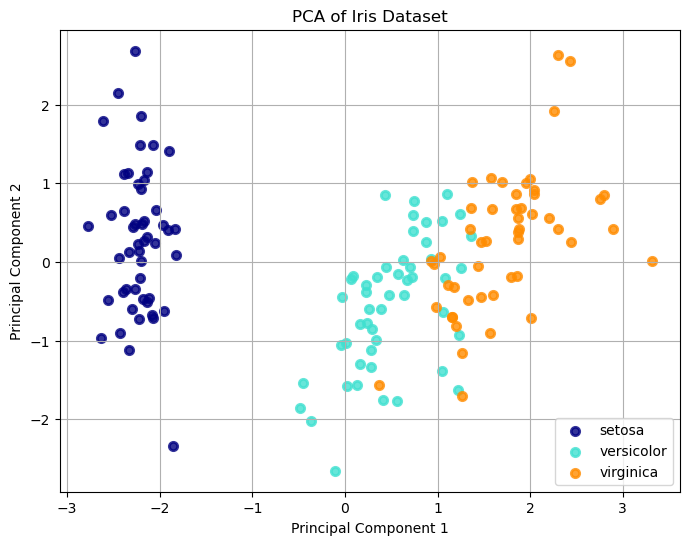

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 2. Standardization
# Cowan's PCA assumes variables are comparable; we scale to unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
# We reduce from 4 dimensions to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Analyze Explained Variance
# This shows how much "information" (variance) each PC captures
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")

# 5. Visualization
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                color=color, alpha=.8, lw=2, label=target_name)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True)
plt.show()